<div class="alert alert-block alert-info">
    <h1>Análisis de Series Temporales</h1>
    <h3>Clase 7</h3>
    <h3>Ejercicio 6</h3>
        <p>Docente: Sebastian Calcagno, Rodrigo Del Rosso, Braian Drago<p>
</div>

# MLForecast y FEDOT sobre una misma serie temporal

**Notebook integral para Google Colab**

Este notebook compara dos enfoques open source sobre exactamente la misma serie:

- **MLForecast (Nixtla):** convierte la serie en una matriz supervisada mediante lags, transformaciones móviles y variables calendario, para luego entrenar regresores compatibles con la API de scikit-learn.
- **FEDOT:** automatiza o permite diseñar manualmente pipelines compuestos de forecasting, incluyendo transformaciones temporales y modelos de regresión.

## Qué se aprenderá

1. Construcción y exploración de una serie temporal.
2. Separación temporal correcta entre entrenamiento y test.
3. Baseline estacional.
4. MLForecast con:
   - regresión lineal;
   - Random Forest;
   - LightGBM;
   - estrategia recursiva;
   - estrategia directa;
   - validación temporal;
   - intervalos conformales;
   - análisis de importancia de variables.
5. FEDOT con:
   - pipeline automático;
   - pipeline manual;
   - visualización de la arquitectura;
   - pronóstico out-of-sample.
6. Comparación homogénea mediante MAE, RMSE, MAPE y sMAPE.

> **Tiempo estimado:** MLForecast suele ejecutarse en pocos minutos. FEDOT puede tardar más porque compone y optimiza pipelines.

Es decir, vamos a comparar dos formas distintas de aplicar Machine Learning y AutoML a series temporales. MLForecast nos permite construir features temporales y entrenar modelos tradicionales de Machine Learning, mientras que FEDOT va un paso mas alla y puede automatizar tambien la estructura completa del pipeline. La idea es comparar ambos enfoques sobre la misma serie, con el mismo test y las mismas metricas

## 1. Instalación

La primera celda instala las dependencias necesarias. En Colab puede aparecer una advertencia solicitando reiniciar el entorno si alguna librería ya estaba cargada.

FEDOT 0.7.5 es la versión estable documentada utilizada en este ejemplo. Si una actualización futura cambia su API, conservar el pin permite reproducir el notebook.

In [ ]:
%%capture
!pip install -q -U mlforecast utilsforecast lightgbm
!pip install -q fedot==0.7.5

## 2. Importaciones, configuración y control de versiones

In [ ]:
import sys
import time
import warnings
import importlib.metadata as metadata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error

from lightgbm import LGBMRegressor

from mlforecast import MLForecast
from mlforecast.lag_transforms import RollingMean, RollingStd, ExpandingMean
from mlforecast.utils import PredictionIntervals

warnings.filterwarnings("ignore")
np.random.seed(42)

print("Python:", sys.version.split()[0])
for package in ["mlforecast", "utilsforecast", "lightgbm", "fedot"]:
    try:
        print(f"{package}: {metadata.version(package)}")
    except metadata.PackageNotFoundError:
        print(f"{package}: no instalado")

Python: 3.13.15
mlforecast: 1.1.0
utilsforecast: 0.2.16
lightgbm: 4.7.0
fedot: no instalado


## 3. Generación de una serie temporal común

Para que el notebook sea autocontenido se genera una serie mensual sintética con:

$$
y_t = \text{nivel}
+ \text{tendencia}_t
+ \text{estacionalidad}_t
+ \text{componente autorregresivo}_t
+ \varepsilon_t
$$

La combinación resulta suficientemente realista para observar diferencias entre modelos sin depender de descargas externas.

El formato de MLForecast es **largo**:

| unique_id | ds | y |
|---|---|---|
| serie_1 | fecha | valor |

Para una única serie, `unique_id` se mantiene constante.

In [ ]:
# Parámetros generales
N = 180                 # 15 años mensuales
H = 18                  # horizonte de test: 18 meses
FREQ = "MS"             # inicio de mes
SEASON_LENGTH = 12
RANDOM_STATE = 42

dates = pd.date_range("2010-01-01", periods=N, freq=FREQ)
t = np.arange(N)

trend = 0.35 * t
seasonal = 14 * np.sin(2 * np.pi * t / 12) + 5 * np.cos(2 * np.pi * t / 6)
noise = np.random.normal(0, 4.0, N)

y = np.zeros(N)
y[0] = 100 + seasonal[0] + noise[0]
for i in range(1, N):
    autoregressive_component = 0.45 * (y[i - 1] - (100 + 0.35 * (i - 1)))
    y[i] = 100 + trend[i] + seasonal[i] + autoregressive_component + noise[i]

# Dos perturbaciones para que la serie no sea excesivamente limpia
y[92:96] -= np.array([8, 15, 10, 5])
y[138:141] += np.array([10, 18, 9])

df = pd.DataFrame({
    "unique_id": "serie_1",
    "ds": dates,
    "y": y.astype(float)
})

df.head(), df.shape

(  unique_id         ds           y
 0   serie_1 2010-01-01  106.986857
 1   serie_1 2010-02-01  112.441028
 2   serie_1 2010-03-01  118.356073
 3   serie_1 2010-04-01  124.087352
 4   serie_1 2010-05-01  120.454551,
 (180, 3))

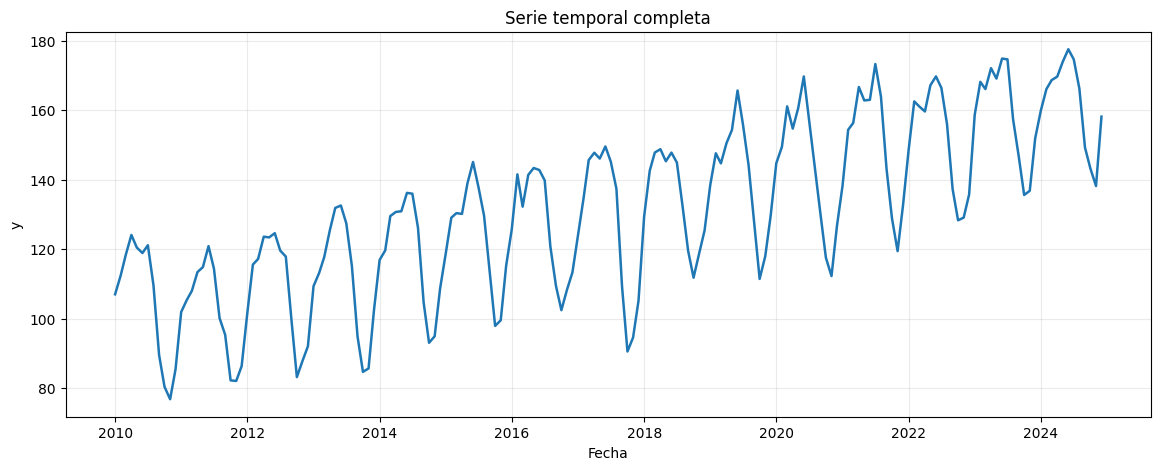

In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(df["ds"], df["y"], linewidth=1.8)
plt.title("Serie temporal completa")
plt.xlabel("Fecha")
plt.ylabel("y")
plt.grid(alpha=0.25)
plt.show()

### Adaptación rápida a un CSV propio

La parte restante del notebook requiere únicamente las columnas:

- `unique_id`: identificador de serie;
- `ds`: fecha;
- `y`: variable objetivo.

Para una sola serie sin identificador se puede crear `unique_id = "serie_1"`.

In [ ]:
# EJEMPLO PARA DATOS PROPIOS — dejar comentado mientras se usa la serie sintética.
#
# from google.colab import files
# uploaded = files.upload()
# nombre_archivo = next(iter(uploaded))
#
# df_usuario = pd.read_csv(nombre_archivo)
# df_usuario["ds"] = pd.to_datetime(df_usuario["fecha"])
# df_usuario["y"] = pd.to_numeric(df_usuario["valor"], errors="coerce")
# df_usuario["unique_id"] = "serie_1"
# df = (
#     df_usuario[["unique_id", "ds", "y"]]
#     .dropna()
#     .sort_values(["unique_id", "ds"])
#     .reset_index(drop=True)
# )

## 4. Split temporal y funciones de evaluación

No se mezclan observaciones aleatoriamente. Los últimos `H` períodos se reservan como test final.

El test no interviene en:

- construcción de features;
- ajuste de parámetros;
- selección de modelos;
- calibración de intervalos.

Train: 2010-01-01 → 2023-06-01 | 162
Test:  2023-07-01 → 2024-12-01 | 18


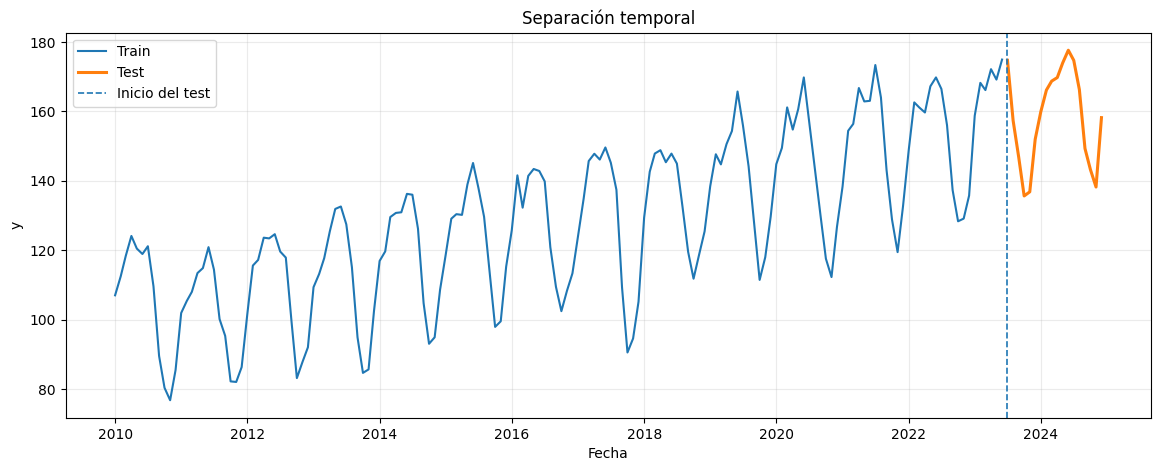

In [ ]:
train_df = df.iloc[:-H].copy()
test_df = df.iloc[-H:].copy()

print("Train:", train_df["ds"].min().date(), "→", train_df["ds"].max().date(), "|", len(train_df))
print("Test: ", test_df["ds"].min().date(), "→", test_df["ds"].max().date(), "|", len(test_df))

plt.figure(figsize=(14, 5))
plt.plot(train_df["ds"], train_df["y"], label="Train")
plt.plot(test_df["ds"], test_df["y"], label="Test", linewidth=2.2)
plt.axvline(test_df["ds"].min(), linestyle="--", linewidth=1.2, label="Inicio del test")
plt.title("Separación temporal")
plt.xlabel("Fecha")
plt.ylabel("y")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

In [ ]:
def mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.abs(y_true) > 1e-8
    return 100 * np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]))

def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denominator = np.abs(y_true) + np.abs(y_pred)
    mask = denominator > 1e-8
    return 100 * np.mean(2 * np.abs(y_pred[mask] - y_true[mask]) / denominator[mask])

def metricas(y_true, y_pred, modelo):
    y_true = np.asarray(y_true, dtype=float).ravel()
    y_pred = np.asarray(y_pred, dtype=float).ravel()
    return {
        "Modelo": modelo,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "MAPE (%)": mape(y_true, y_pred),
        "sMAPE (%)": smape(y_true, y_pred),
    }

def grafico_forecast(train, test, pred, titulo, intervalo=None):
    plt.figure(figsize=(14, 5))
    historial = train.tail(60)
    plt.plot(historial["ds"], historial["y"], label="Histórico")
    plt.plot(test["ds"], test["y"], label="Real", linewidth=2.3)
    plt.plot(test["ds"], pred, label="Pronóstico", linewidth=2.1)

    if intervalo is not None:
        lower, upper = intervalo
        plt.fill_between(test["ds"], lower, upper, alpha=0.20, label="Intervalo")

    plt.axvline(test["ds"].min(), linestyle="--", linewidth=1)
    plt.title(titulo)
    plt.xlabel("Fecha")
    plt.ylabel("y")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()

resultados = []

## 5. Baseline estacional

Antes de probar algoritmos complejos se construye un baseline:

$$
\hat{y}_{t+h} = y_{t+h-12}
$$

En una serie mensual, repite el valor observado doce meses antes. Un modelo complejo debería mejorar esta referencia para justificar su uso.

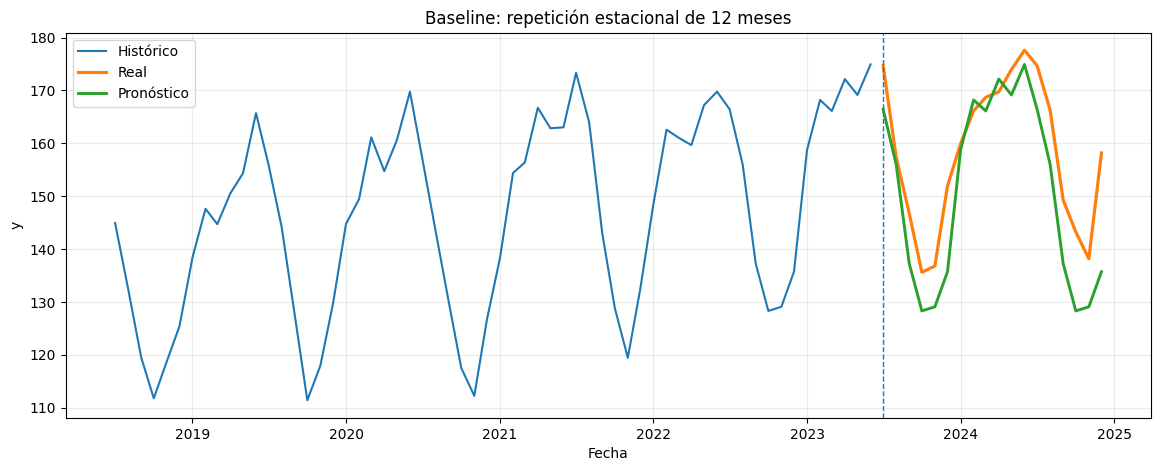

,Modelo,MAE,RMSE,MAPE (%),sMAPE (%)
0,Naive estacional,7.948,9.751,5.172,5.385


In [ ]:
naive_pred = np.resize(train_df["y"].iloc[-SEASON_LENGTH:].to_numpy(), H)

resultados.append(metricas(test_df["y"], naive_pred, "Naive estacional"))
grafico_forecast(
    train_df, test_df, naive_pred,
    "Baseline: repetición estacional de 12 meses"
)

pd.DataFrame(resultados).round(3)

# Parte A — MLForecast

## 6. Concepto

MLForecast construye automáticamente variables como:

- \(y_{t-1}\), \(y_{t-2}\), \(y_{t-12}\);
- promedio móvil;
- desvío móvil;
- media expansiva;
- mes, trimestre y año.

Luego ajusta regresores tradicionales sobre esa tabla.

### Estrategias cubiertas

**Recursiva**

Entrena un modelo a un paso. Para pronosticar varios períodos, utiliza predicciones anteriores como nuevos lags.

**Directa**

Entrena un modelo diferente para cada paso del horizonte. Evita propagar predicciones de forma recursiva, pero aumenta el costo computacional.

## 7. MLForecast recursivo con varios regresores

In [ ]:
modelos_ml = {
    "RegresionLineal": LinearRegression(),
    "RandomForest": RandomForestRegressor(
        n_estimators=400,
        max_depth=8,
        min_samples_leaf=3,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "LightGBM": LGBMRegressor(
        n_estimators=500,
        learning_rate=0.035,
        num_leaves=20,
        max_depth=-1,
        min_child_samples=12,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=RANDOM_STATE,
        verbosity=-1
    )
}

mlf_rec = MLForecast(
    models=modelos_ml,
    freq=FREQ,
    lags=[1, 2, 3, 6, 12, 13, 18, 24],
    lag_transforms={
        1: [
            RollingMean(window_size=3),
            RollingMean(window_size=6),
            RollingStd(window_size=6),
            ExpandingMean()
        ],
        12: [
            RollingMean(window_size=3),
            RollingMean(window_size=6)
        ]
    },
    date_features=["month", "quarter", "year"]
)

inicio = time.perf_counter()
mlf_rec.fit(
    train_df,
    id_col="unique_id",
    time_col="ds",
    target_col="y",
    static_features=[]
)
tiempo_mlf_rec = time.perf_counter() - inicio

pred_rec = mlf_rec.predict(h=H)
print(f"Tiempo de ajuste: {tiempo_mlf_rec:.2f} segundos")
pred_rec.head()

Tiempo de ajuste: 1.67 segundos


,unique_id,ds,RegresionLineal,RandomForest,LightGBM
0,serie_1,2023-07-01,172.942344,170.549163,169.370095
1,serie_1,2023-08-01,165.442344,170.178428,168.328707
2,serie_1,2023-09-01,149.942344,148.821794,150.154785
3,serie_1,2023-10-01,136.192344,137.593709,138.687688
4,serie_1,2023-11-01,130.692344,130.168319,130.976279


### Visualización conjunta

Cada columna de predicción corresponde a un regresor distinto, pero todos utilizan el mismo conjunto de features temporales.

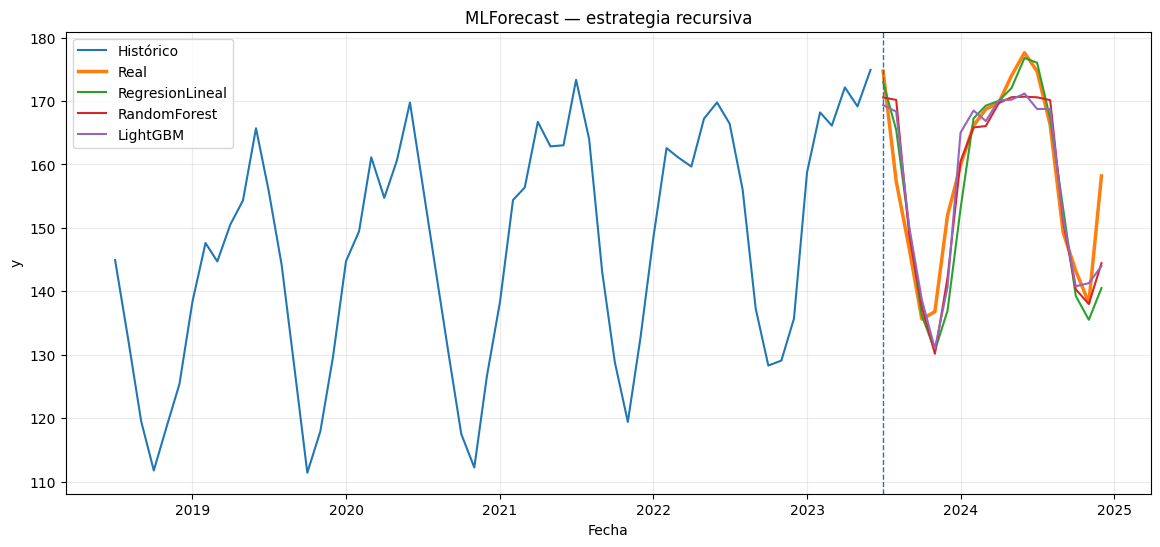

In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(train_df.tail(60)["ds"], train_df.tail(60)["y"], label="Histórico")
plt.plot(test_df["ds"], test_df["y"], label="Real", linewidth=2.5)

for nombre in modelos_ml:
    plt.plot(pred_rec["ds"], pred_rec[nombre], label=nombre)

plt.axvline(test_df["ds"].min(), linestyle="--", linewidth=1)
plt.title("MLForecast — estrategia recursiva")
plt.xlabel("Fecha")
plt.ylabel("y")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

In [ ]:
for nombre in modelos_ml:
    resultados.append(metricas(test_df["y"], pred_rec[nombre], f"MLForecast rec. — {nombre}"))

tabla_mlf_rec = (
    pd.DataFrame(resultados)
    .sort_values("RMSE")
    .reset_index(drop=True)
)
tabla_mlf_rec.round(3)

,Modelo,MAE,RMSE,MAPE (%),sMAPE (%)
0,MLForecast rec. — RandomForest,4.329,5.912,2.744,2.774
1,MLForecast rec. — LightGBM,5.013,6.174,3.187,3.222
2,MLForecast rec. — RegresionLineal,4.262,6.438,2.771,2.840
3,Naive estacional,7.948,9.751,5.172,5.385


## 8. Inspección de la matriz supervisada creada por MLForecast

`preprocess` permite observar cómo la serie se transforma en una tabla apta para machine learning.

Las primeras filas se eliminan porque todavía no existe historia suficiente para calcular los lags más largos.

In [ ]:
features_train = mlf_rec.preprocess(
    train_df,
    id_col="unique_id",
    time_col="ds",
    target_col="y",
    static_features=[]
)

print("Dimensión de la matriz:", features_train.shape)
display(features_train.head())
display(features_train.tail())

Dimensión de la matriz: (138, 20)


,unique_id,ds,y,lag1,lag2,lag3,lag6,lag12,lag13,lag18,lag24,rolling_mean_lag1_window_size3,rolling_mean_lag1_window_size6,rolling_std_lag1_window_size6,expanding_mean_lag1,rolling_mean_lag12_window_size3,rolling_mean_lag12_window_size6,month,quarter,year
24,serie_1,2012-01-01,101.433034,86.295701,82.021541,82.185074,114.378878,101.889047,85.452663,121.128951,106.986857,83.500772,93.387423,12.608265,103.692891,88.032853,90.587905,1,1,2012
25,serie_1,2012-02-01,115.558556,101.433034,86.295701,82.021541,100.136281,105.356950,101.889047,109.582767,112.441028,89.916758,91.229783,8.843076,103.602497,97.566220,89.883602,2,1,2012
26,serie_1,2012-03-01,117.184231,115.558556,101.433034,86.295701,95.307066,107.987812,105.356950,89.507492,118.356073,101.095764,93.800162,13.144750,104.062345,105.077937,92.963655,3,1,2012
27,serie_1,2012-04-01,123.590696,117.184231,115.558556,101.433034,82.185074,113.390365,107.987812,80.338612,124.087352,111.391941,97.446356,16.301521,104.548341,108.911709,98.472281,4,2,2012
28,serie_1,2012-05-01,123.385114,123.590696,117.184231,115.558556,82.021541,114.836196,113.390365,76.756849,120.454551,118.777828,104.347293,17.283403,105.228425,112.071458,104.818839,5,2,2012


,unique_id,ds,y,lag1,lag2,lag3,lag6,lag12,lag13,lag18,lag24,rolling_mean_lag1_window_size3,rolling_mean_lag1_window_size6,rolling_std_lag1_window_size6,expanding_mean_lag1,rolling_mean_lag12_window_size3,rolling_mean_lag12_window_size6,month,quarter,year
157,serie_1,2023-02-01,168.203154,158.728495,135.728660,129.091257,156.005210,162.574966,148.617055,163.993445,154.395889,141.182804,140.856992,13.294905,126.831798,147.952914,139.207861,2,1,2023
158,serie_1,2023-03-01,166.123061,168.203154,158.728495,135.728660,137.275390,161.097788,162.574966,143.090034,156.377309,154.220103,142.889983,16.597098,127.093642,157.429937,142.209153,3,1,2023
159,serie_1,2023-04-01,172.146592,166.123061,168.203154,158.728495,128.312940,159.667178,161.097788,128.869086,166.714527,164.351570,147.697928,18.691563,127.339110,161.113311,147.342168,4,2,2023
160,serie_1,2023-05-01,169.149095,172.146592,166.123061,168.203154,129.091257,167.209852,159.667178,119.429300,162.850379,168.824269,155.003537,18.158196,127.619156,162.658273,155.305593,5,2,2023
161,serie_1,2023-06-01,174.915431,169.149095,172.146592,166.123061,135.728660,169.772372,167.209852,132.666721,163.024425,169.139583,161.679843,13.489349,127.877106,165.549801,161.489869,6,2,2023


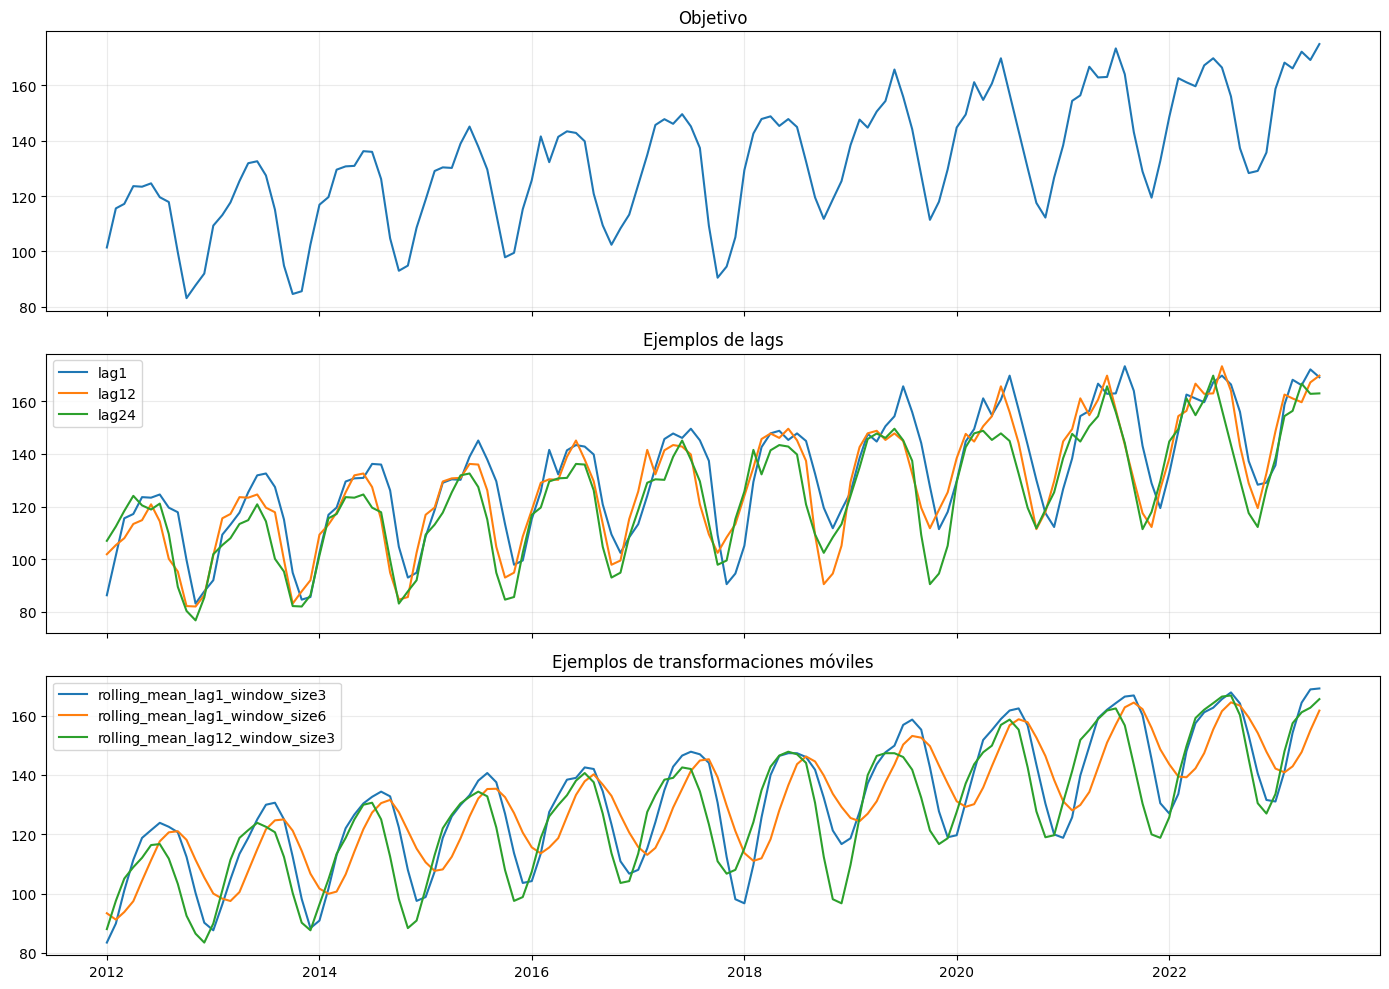

In [ ]:
columnas_features = [
    c for c in features_train.columns
    if c not in ["unique_id", "ds", "y"]
]

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(features_train["ds"], features_train["y"], label="Objetivo y")
axes[0].set_title("Objetivo")

for c in ["lag1", "lag12", "lag24"]:
    if c in features_train:
        axes[1].plot(features_train["ds"], features_train[c], label=c)
axes[1].set_title("Ejemplos de lags")
axes[1].legend()

rolling_cols = [c for c in columnas_features if "rolling_mean" in c][:3]
for c in rolling_cols:
    axes[2].plot(features_train["ds"], features_train[c], label=c)
axes[2].set_title("Ejemplos de transformaciones móviles")
axes[2].legend()

for ax in axes:
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

## 9. Validación temporal con ventanas móviles

La validación temporal simula múltiples pronósticos históricos:

1. ajusta usando información disponible hasta un corte;
2. pronostica los siguientes `H_CV` períodos;
3. avanza el corte;
4. repite.

Esto es preferible a una validación aleatoria porque conserva el orden temporal.

In [ ]:
H_CV = 12
N_WINDOWS = 4

mlf_cv = MLForecast(
    models={
        "Ridge": Ridge(alpha=1.0),
        "LightGBM": clone(modelos_ml["LightGBM"])
    },
    freq=FREQ,
    lags=[1, 2, 3, 6, 12, 13, 18, 24],
    lag_transforms={
        1: [RollingMean(3), RollingMean(6), RollingStd(6)],
        12: [RollingMean(3)]
    },
    date_features=["month", "quarter"]
)

cv_df = mlf_cv.cross_validation(
    df=train_df,
    n_windows=N_WINDOWS,
    h=H_CV,
    step_size=H_CV,
    id_col="unique_id",
    time_col="ds",
    target_col="y",
    static_features=[],
    refit=True
)

cv_df.head()

,unique_id,ds,cutoff,y,Ridge,LightGBM
0,serie_1,2019-07-01,2019-06-01,155.902376,158.209101,145.304575
1,serie_1,2019-08-01,2019-06-01,144.157258,144.065007,140.528079
2,serie_1,2019-09-01,2019-06-01,127.595064,122.442260,123.352330
3,serie_1,2019-10-01,2019-06-01,111.423066,106.555444,103.555328
4,serie_1,2019-11-01,2019-06-01,117.959816,108.025965,111.526163


In [ ]:
model_cols_cv = ["Ridge", "LightGBM"]
filas_cv = []

for cutoff, bloque in cv_df.groupby("cutoff"):
    for nombre in model_cols_cv:
        met = metricas(bloque["y"], bloque[nombre], nombre)
        met["Cutoff"] = pd.Timestamp(cutoff)
        filas_cv.append(met)

metricas_cv = pd.DataFrame(filas_cv)
display(metricas_cv.round(3))

resumen_cv = (
    metricas_cv
    .groupby("Modelo")[["MAE", "RMSE", "MAPE (%)", "sMAPE (%)"]]
    .agg(["mean", "std"])
)
resumen_cv.round(3)

,Modelo,MAE,RMSE,MAPE (%),sMAPE (%),Cutoff
0,Ridge,5.622,6.838,4.050,4.177,2019-06-01
1,LightGBM,9.531,11.096,6.464,6.741,2019-06-01
2,Ridge,5.451,6.721,3.942,3.840,2020-06-01
3,LightGBM,5.007,6.135,3.631,3.560,2020-06-01
4,Ridge,5.866,7.814,3.773,3.882,2021-06-01
5,LightGBM,5.822,6.971,3.758,3.855,2021-06-01
6,Ridge,4.324,5.162,2.858,2.885,2022-06-01
7,LightGBM,6.366,7.868,4.136,4.181,2022-06-01


MAE          RMSE        MAPE (%)        sMAPE (%)       
           mean    std   mean    std     mean    std      mean    std
Modelo                                                               
LightGBM  6.682  1.980  8.017  2.171    4.497  1.329     4.584  1.460
Ridge     5.316  0.683  6.634  1.097    3.656  0.544     3.696  0.561

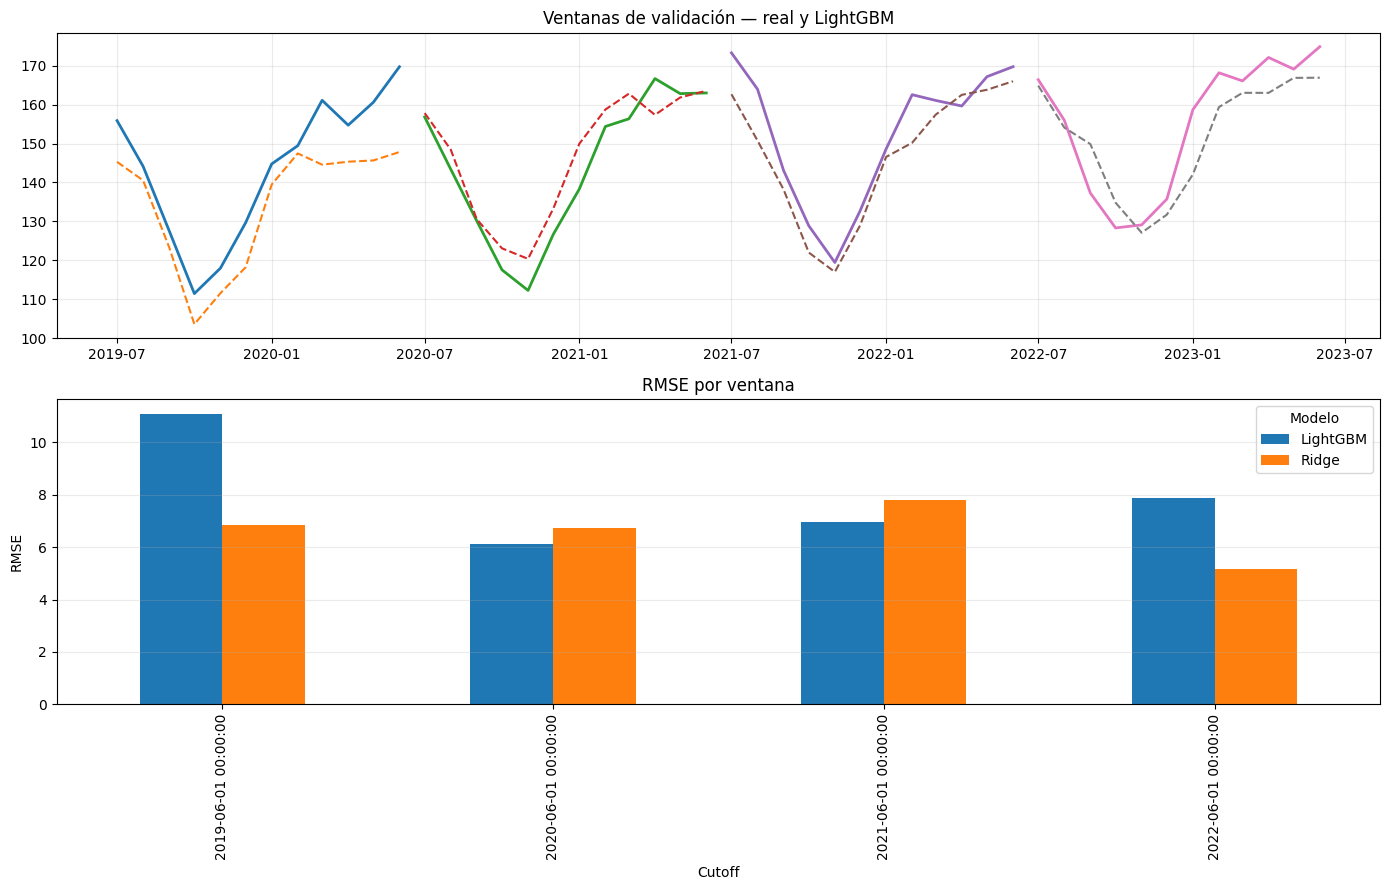

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=False)

for cutoff, bloque in cv_df.groupby("cutoff"):
    axes[0].plot(bloque["ds"], bloque["y"], linewidth=2)
    axes[0].plot(bloque["ds"], bloque["LightGBM"], linestyle="--")
axes[0].set_title("Ventanas de validación — real y LightGBM")
axes[0].grid(alpha=0.25)

rmse_pivot = metricas_cv.pivot(index="Cutoff", columns="Modelo", values="RMSE")
rmse_pivot.plot(kind="bar", ax=axes[1])
axes[1].set_title("RMSE por ventana")
axes[1].set_ylabel("RMSE")
axes[1].grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

## 10. Estrategia directa: un modelo por horizonte

Con `max_horizon=H`, MLForecast entrena:

- un modelo para \(t+1\);
- otro para \(t+2\);
- ...
- otro para \(t+H\).

Para mantener el tiempo de ejecución razonable se utiliza LightGBM. La estrategia directa puede ser útil cuando los mecanismos predictivos cambian según la distancia del horizonte.

In [ ]:
mlf_direct = MLForecast(
    models={
        "LightGBM_directo": clone(modelos_ml["LightGBM"])
    },
    freq=FREQ,
    lags=[1, 2, 3, 6, 12, 13, 18, 24],
    lag_transforms={
        1: [RollingMean(3), RollingMean(6), RollingStd(6)],
        12: [RollingMean(3)]
    },
    date_features=["month", "quarter"],
    max_horizon=H
)

inicio = time.perf_counter()
mlf_direct.fit(
    train_df,
    id_col="unique_id",
    time_col="ds",
    target_col="y",
    static_features=[]
)
tiempo_directo = time.perf_counter() - inicio

pred_direct = mlf_direct.predict(h=H)
print(f"Tiempo de ajuste directo: {tiempo_directo:.2f} segundos")
pred_direct.head()

TypeError: MLForecast.__init__() got an unexpected keyword argument 'max_horizon'

In [ ]:
mlf_direct = MLForecast(
    models={
        "LightGBM_directo": clone(modelos_ml["LightGBM"])
    },
    freq=FREQ,
    lags=[1, 2, 3, 6, 12, 13, 18, 24],
    lag_transforms={
        1: [
            RollingMean(window_size=3),
            RollingMean(window_size=6),
            RollingStd(window_size=6)
        ],
        12: [
            RollingMean(window_size=3)
        ]
    },
    date_features=["month", "quarter"]
)

inicio = time.perf_counter()

mlf_direct.fit(
    train_df,
    id_col="unique_id",
    time_col="ds",
    target_col="y",
    static_features=[],
    max_horizon=H
)

tiempo_directo = time.perf_counter() - inicio

pred_direct = mlf_direct.predict(h=H)

print(
    f"Tiempo de ajuste directo: "
    f"{tiempo_directo:.2f} segundos"
)

pred_direct.head()

Tiempo de ajuste directo: 3.13 segundos


,unique_id,ds,LightGBM_directo
0,serie_1,2023-07-01,170.081660
1,serie_1,2023-08-01,154.950212
2,serie_1,2023-09-01,133.271589
3,serie_1,2023-10-01,138.949376
4,serie_1,2023-11-01,143.986144


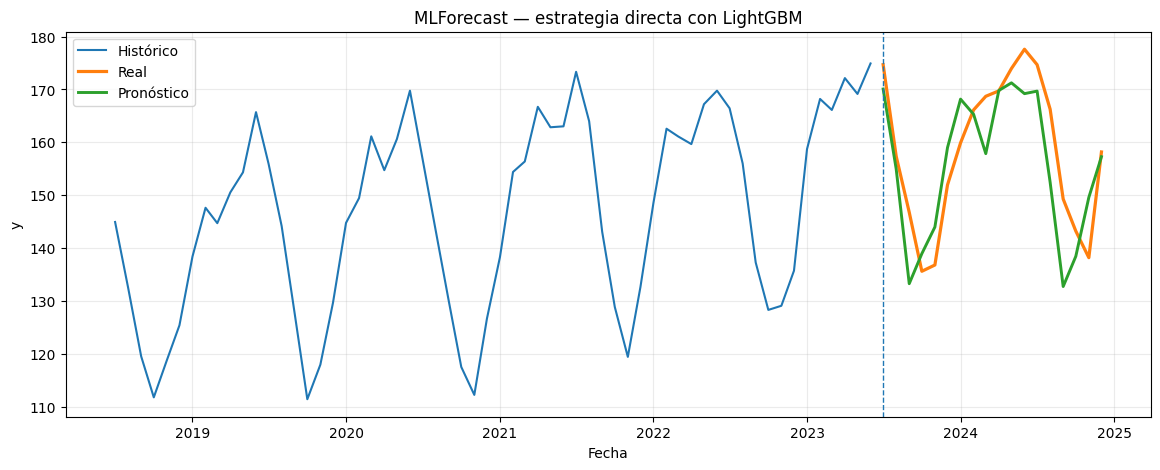

,Modelo,MAE,RMSE,MAPE (%),sMAPE (%)
2,MLForecast rec. — RandomForest,4.329,5.912,2.744,2.774
3,MLForecast rec. — LightGBM,5.013,6.174,3.187,3.222
1,MLForecast rec. — RegresionLineal,4.262,6.438,2.771,2.840
4,MLForecast directo — LightGBM,6.759,8.266,4.364,4.432
0,Naive estacional,7.948,9.751,5.172,5.385


In [ ]:
resultados.append(
    metricas(test_df["y"], pred_direct["LightGBM_directo"], "MLForecast directo — LightGBM")
)

grafico_forecast(
    train_df,
    test_df,
    pred_direct["LightGBM_directo"],
    "MLForecast — estrategia directa con LightGBM"
)

pd.DataFrame(resultados).sort_values("RMSE").round(3)

## 11. Intervalos de predicción conformales

Los intervalos se calibran usando errores históricos generados mediante ventanas temporales.

- El pronóstico puntual estima el valor central.
- El intervalo refleja incertidumbre empírica.
- `level=[80, 95]` solicita intervalos del 80 % y 95 %.

Los intervalos no garantizan cobertura perfecta en cada muestra, pero ofrecen una aproximación práctica y libre de supuestos distribucionales fuertes.

In [ ]:
mlf_intervalos = MLForecast(
    models={
        "LightGBM": clone(modelos_ml["LightGBM"])
    },
    freq=FREQ,
    lags=[1, 2, 3, 6, 12, 13, 18, 24],
    lag_transforms={
        1: [RollingMean(3), RollingMean(6), RollingStd(6)],
        12: [RollingMean(3)]
    },
    date_features=["month", "quarter"]
)

mlf_intervalos.fit(
    train_df,
    id_col="unique_id",
    time_col="ds",
    target_col="y",
    static_features=[],
    prediction_intervals=PredictionIntervals(
        n_windows=4,
        h=H,
        method="conformal_distribution"
    )
)

pred_intervalos = mlf_intervalos.predict(h=H, level=[80, 95])
pred_intervalos.head()

,unique_id,ds,LightGBM,LightGBM-lo-95,LightGBM-lo-80,LightGBM-hi-80,LightGBM-hi-95
0,serie_1,2023-07-01,170.081660,150.743772,154.576950,185.586369,189.419547
1,serie_1,2023-08-01,169.098289,151.596815,152.921420,185.275159,186.599764
2,serie_1,2023-09-01,150.344515,127.895012,134.948338,165.740693,172.794019
3,serie_1,2023-10-01,138.470958,115.831215,117.698320,159.243595,161.110700
4,serie_1,2023-11-01,129.120454,104.775187,106.952772,151.288137,153.465722


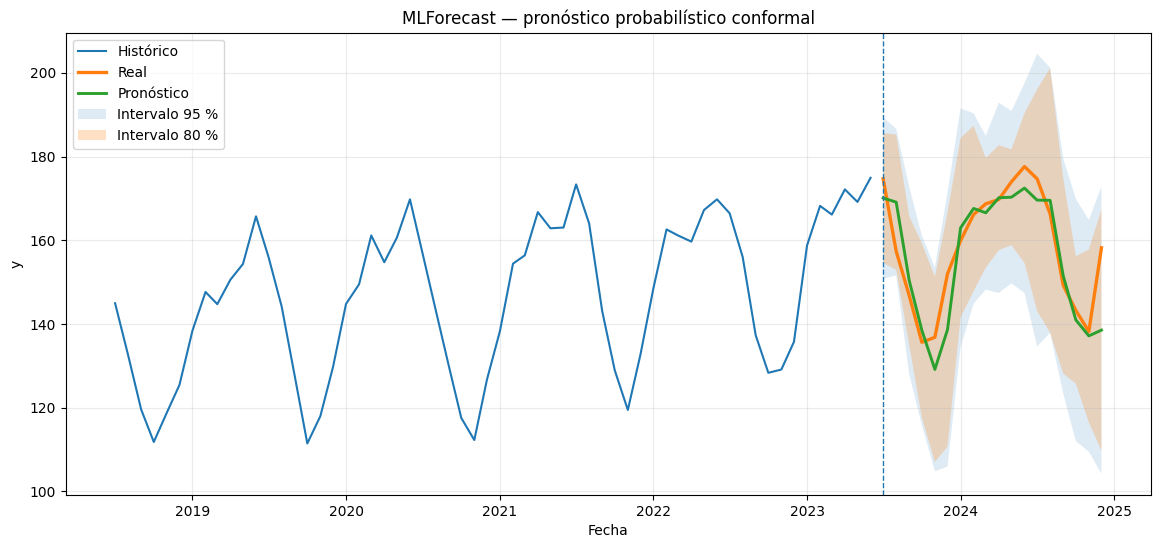

Cobertura observada del intervalo 95 % en el test: 100.0 %


In [ ]:
lower_95 = pred_intervalos["LightGBM-lo-95"]
upper_95 = pred_intervalos["LightGBM-hi-95"]

plt.figure(figsize=(14, 6))
plt.plot(train_df.tail(60)["ds"], train_df.tail(60)["y"], label="Histórico")
plt.plot(test_df["ds"], test_df["y"], label="Real", linewidth=2.4)
plt.plot(pred_intervalos["ds"], pred_intervalos["LightGBM"], label="Pronóstico", linewidth=2.1)

plt.fill_between(
    pred_intervalos["ds"],
    pred_intervalos["LightGBM-lo-95"],
    pred_intervalos["LightGBM-hi-95"],
    alpha=0.14,
    label="Intervalo 95 %"
)
plt.fill_between(
    pred_intervalos["ds"],
    pred_intervalos["LightGBM-lo-80"],
    pred_intervalos["LightGBM-hi-80"],
    alpha=0.24,
    label="Intervalo 80 %"
)

plt.axvline(test_df["ds"].min(), linestyle="--", linewidth=1)
plt.title("MLForecast — pronóstico probabilístico conformal")
plt.xlabel("Fecha")
plt.ylabel("y")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

cobertura_95 = np.mean(
    (test_df["y"].to_numpy() >= lower_95.to_numpy()) &
    (test_df["y"].to_numpy() <= upper_95.to_numpy())
)
print(f"Cobertura observada del intervalo 95 % en el test: {100*cobertura_95:.1f} %")

## 12. Importancia de variables del LightGBM recursivo

MLForecast deja disponibles los modelos ya ajustados en `models_`.

La importancia de LightGBM indica qué variables fueron utilizadas con mayor frecuencia o aporte en los árboles. No debe interpretarse automáticamente como causalidad.

,feature,importance
0,lag1,421
6,lag18,421
7,lag24,417
3,lag6,406
2,lag3,329
4,lag12,316
11,expanding_mean_lag1,310
10,rolling_std_lag1_window_size6,298
13,rolling_mean_lag12_window_size6,250
9,rolling_mean_lag1_window_size6,190


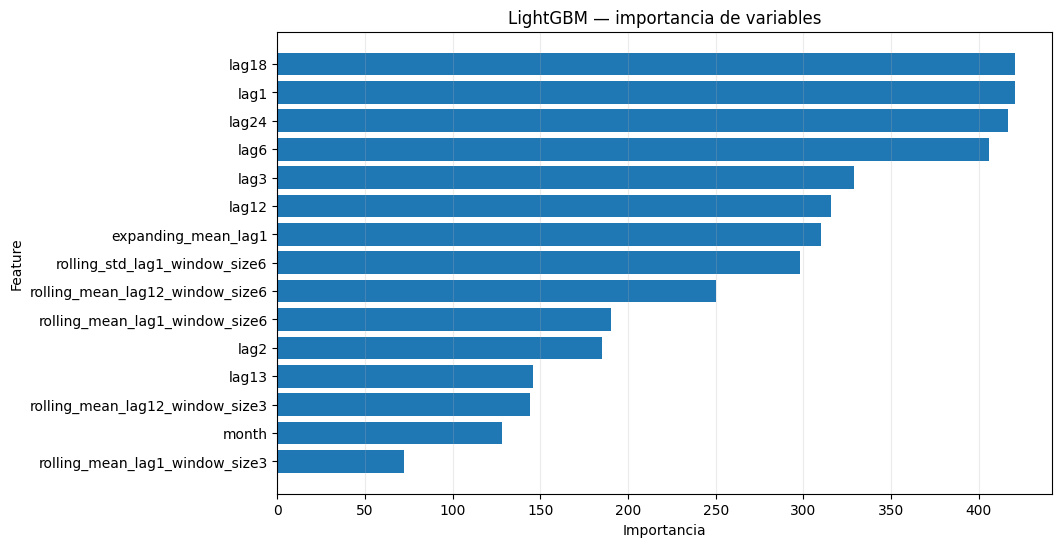

In [ ]:
modelo_lgbm_entrenado = mlf_rec.models_["LightGBM"]

importancias = pd.DataFrame({
    "feature": modelo_lgbm_entrenado.feature_name_,
    "importance": modelo_lgbm_entrenado.feature_importances_
}).sort_values("importance", ascending=False)

display(importancias.head(15))

plt.figure(figsize=(10, 6))
top_imp = importancias.head(15).sort_values("importance")
plt.barh(top_imp["feature"], top_imp["importance"])
plt.title("LightGBM — importancia de variables")
plt.xlabel("Importancia")
plt.ylabel("Feature")
plt.grid(axis="x", alpha=0.25)
plt.show()

https://github.com/aimclub/FEDOT

# Parte B — FEDOT

## 13. Concepto

FEDOT modela el problema como un **pipeline compuesto**.

Ejemplo conceptual:

$$
\text{Serie temporal}
\;\longrightarrow\;
\text{transformación mediante rezagos}
\;\longrightarrow\;
\text{modelo de regresión}
\;\longrightarrow\;
\text{pronóstico}
$$

En modo automático, FEDOT busca una arquitectura y ajusta hiperparámetros. En modo manual, el usuario define explícitamente la secuencia de nodos.

> La búsqueda automática puede demorar. El parámetro `timeout` se expresa en minutos.

## 14. Preparación de la misma serie para FEDOT

FEDOT utiliza su propio objeto `InputData`.

El `forecast_length` debe coincidir con el horizonte para el cual se entrenará el pipeline. Se crea el objeto usando solamente el tramo de entrenamiento; el test permanece completamente externo.

In [ ]:
from fedot.api.main import Fedot
from fedot.core.data.data import InputData
from fedot.core.pipelines.pipeline_builder import PipelineBuilder
from fedot.core.repository.tasks import Task, TaskTypesEnum, TsForecastingParams

task_fedot = Task(
    TaskTypesEnum.ts_forecasting,
    TsForecastingParams(forecast_length=H)
)

serie_train = train_df["y"].to_numpy(dtype=float)

fedot_train = InputData.from_numpy_time_series(
    features_array=serie_train,
    target_array=serie_train,
    task=task_fedot
)

print("Longitud de entrenamiento:", len(serie_train))
print("Horizonte FEDOT:", H)

Longitud de entrenamiento: 162
Horizonte FEDOT: 18


## 15. FEDOT automático

Configuración orientada a Colab:

- `timeout=3`: limita la composición a aproximadamente tres minutos;
- `n_jobs=-1`: utiliza los núcleos disponibles;
- `cv_folds=2`: validación interna temporal;
- `preset="fast_train"`: prioriza velocidad.

Para una búsqueda más profunda, aumentar `timeout` a 10–30 minutos y quitar o cambiar el preset.

In [ ]:
fedot_auto = Fedot(
    problem="ts_forecasting",
    task_params=task_fedot.task_params,
    timeout=3,
    n_jobs=-1,
    cv_folds=2,
    preset="fast_train",
    seed=RANDOM_STATE,
    logging_level=20
)

inicio = time.perf_counter()
pipeline_auto = fedot_auto.fit(fedot_train)
tiempo_fedot_auto = time.perf_counter() - inicio

forecast_auto = np.asarray(
    fedot_auto.forecast(fedot_train, horizon=H)
).ravel()

print(f"Tiempo FEDOT automático: {tiempo_fedot_auto:.2f} segundos")
print("Pipeline encontrado:")
print(pipeline_auto)

Level 100:root:Extra dependencies for time series forecasting are not installed. It can infuence the performance. Please install it by 'pip install fedot[extra]'


2026-08-08 20:39:54,112 - Extra dependencies for time series forecasting are not installed. It can infuence the performance. Please install it by 'pip install fedot[extra]'


Level 100:root:Topological features operation requires extra dependencies for time series forecasting, which are not installed. It can infuence the performance. Please install it by 'pip install fedot[extra]'


2026-08-08 20:40:27,707 - Topological features operation requires extra dependencies for time series forecasting, which are not installed. It can infuence the performance. Please install it by 'pip install fedot[extra]'


INFO:root:AssumptionsHandler - Initial pipeline fitting started


...

2026-08-08 20:43:33,281 - FEDOT logger - Final pipeline was fitted


Level 45:root:FEDOT logger - Final pipeline: {'depth': 2, 'length': 2, 'nodes': [ridge, lagged]}
ridge - {'alpha': 5.267953179888966}
lagged - {'window_size': 17.019473185438407}


2026-08-08 20:43:33,287 - FEDOT logger - Final pipeline: {'depth': 2, 'length': 2, 'nodes': [ridge, lagged]}
ridge - {'alpha': 5.267953179888966}
lagged - {'window_size': 17.019473185438407}


INFO:root:MemoryAnalytics - Memory consumption for finish in main session: current 163.7 MiB, max: 170.3 MiB


2026-08-08 20:43:33,291 - MemoryAnalytics - Memory consumption for finish in main session: current 163.7 MiB, max: 170.3 MiB
Tiempo FEDOT automático: 220.04 segundos
Pipeline encontrado:
{'depth': 2, 'length': 2, 'nodes': [ridge, lagged]}


### Arquitectura del pipeline

`pipeline.show()` intenta dibujar el grafo. Dependiendo de la versión de Graphviz disponible en Colab, puede abrir una imagen o mostrar la representación del pipeline.

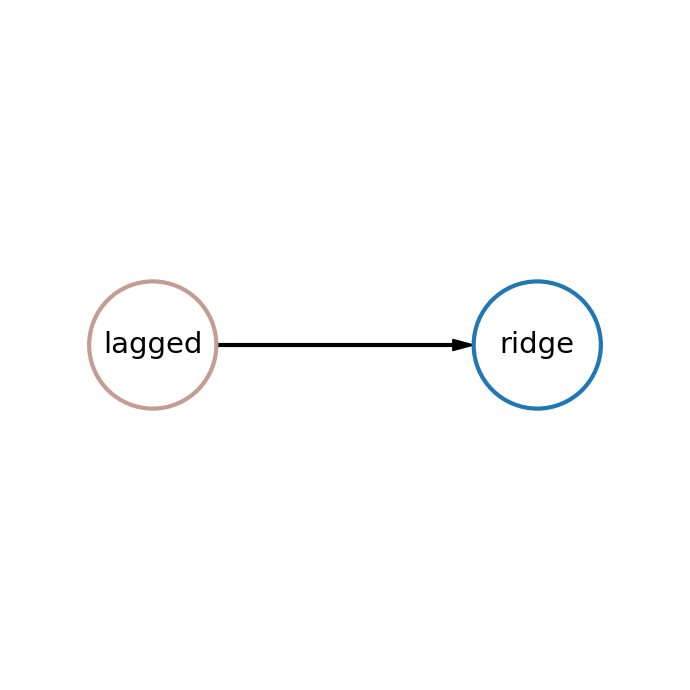

In [ ]:
try:
    pipeline_auto.show()
except Exception as error:
    print("No se pudo renderizar el grafo automáticamente.")
    print("Representación textual:", pipeline_auto)
    print("Detalle técnico:", error)

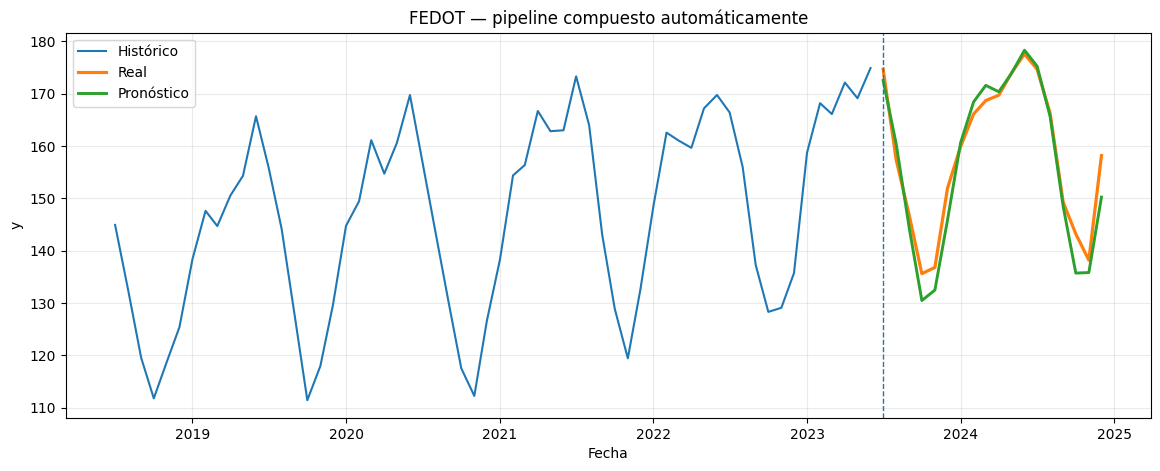

,Modelo,MAE,RMSE,MAPE (%),sMAPE (%)
5,FEDOT automático,2.797,3.676,1.854,1.880
2,MLForecast rec. — RandomForest,4.329,5.912,2.744,2.774
3,MLForecast rec. — LightGBM,5.013,6.174,3.187,3.222
1,MLForecast rec. — RegresionLineal,4.262,6.438,2.771,2.840
4,MLForecast directo — LightGBM,6.759,8.266,4.364,4.432
0,Naive estacional,7.948,9.751,5.172,5.385


In [ ]:
resultados.append(
    metricas(test_df["y"], forecast_auto, "FEDOT automático")
)

grafico_forecast(
    train_df,
    test_df,
    forecast_auto,
    "FEDOT — pipeline compuesto automáticamente"
)

pd.DataFrame(resultados).sort_values("RMSE").round(3)

## 16. FEDOT manual: lagged → ridge

Este pipeline implementa una variante interpretable:

1. `lagged`: transforma la serie en una matriz supervisada;
2. `ridge`: ajusta una regresión lineal regularizada.

La ventaja es el control total sobre la arquitectura. La desventaja es que ya no se automatiza la selección estructural.

In [ ]:
pipeline_manual = (
    PipelineBuilder()
    .add_sequence("lagged", "ridge")
    .build()
)

fedot_manual = Fedot(
    problem="ts_forecasting",
    task_params=task_fedot.task_params,
    n_jobs=-1,
    seed=RANDOM_STATE,
    logging_level=20
)

inicio = time.perf_counter()
fedot_manual.fit(
    fedot_train,
    predefined_model=pipeline_manual
)
tiempo_fedot_manual = time.perf_counter() - inicio

forecast_manual = np.asarray(
    fedot_manual.forecast(fedot_train, horizon=H)
).ravel()

print(f"Tiempo FEDOT manual: {tiempo_fedot_manual:.2f} segundos")
print("Pipeline:", pipeline_manual)

Level 100:root:Extra dependencies for time series forecasting are not installed. It can infuence the performance. Please install it by 'pip install fedot[extra]'


2026-08-08 20:43:53,787 - Extra dependencies for time series forecasting are not installed. It can infuence the performance. Please install it by 'pip install fedot[extra]'


Level 100:root:Extra dependencies for time series forecasting are not installed. It can infuence the performance. Please install it by 'pip install fedot[extra]'


2026-08-08 20:43:53,793 - Extra dependencies for time series forecasting are not installed. It can infuence the performance. Please install it by 'pip install fedot[extra]'


Level 100:root:Extra dependencies for time series forecasting are not installed. It can infuence the performance. Please install it by 'pip install fedot[extra]'


...

2026-08-08 20:43:53,822 - LaggedTransformationImplementation - Window size of lagged transformation was changed by WindowSizeSelector from 0 to 11


Level 45:root:FEDOT logger - Final pipeline: {'depth': 2, 'length': 2, 'nodes': [ridge, lagged]}
ridge - {}
lagged - {'window_size': 11}


2026-08-08 20:43:53,842 - FEDOT logger - Final pipeline: {'depth': 2, 'length': 2, 'nodes': [ridge, lagged]}
ridge - {}
lagged - {'window_size': 11}


INFO:root:MemoryAnalytics - Memory consumption for finish in main session: current 0.0 MiB, max: 0.2 MiB


2026-08-08 20:43:53,847 - MemoryAnalytics - Memory consumption for finish in main session: current 0.0 MiB, max: 0.2 MiB
Tiempo FEDOT manual: 0.07 segundos
Pipeline: {'depth': 2, 'length': 2, 'nodes': [ridge, lagged]}


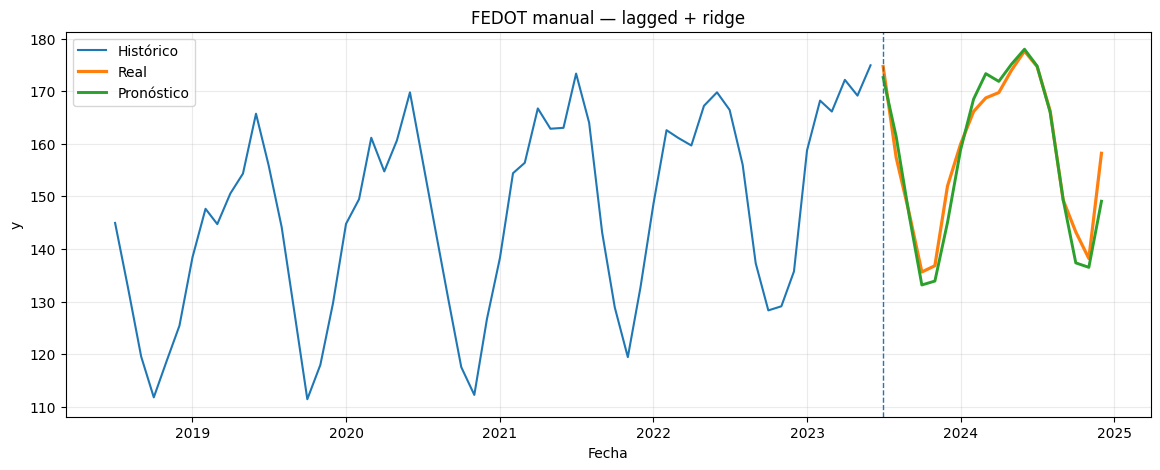

,Modelo,MAE,RMSE,MAPE (%),sMAPE (%)
6,FEDOT manual — lagged + ridge,2.644,3.631,1.712,1.730
5,FEDOT automático,2.797,3.676,1.854,1.880
2,MLForecast rec. — RandomForest,4.329,5.912,2.744,2.774
3,MLForecast rec. — LightGBM,5.013,6.174,3.187,3.222
1,MLForecast rec. — RegresionLineal,4.262,6.438,2.771,2.840
4,MLForecast directo — LightGBM,6.759,8.266,4.364,4.432
0,Naive estacional,7.948,9.751,5.172,5.385


In [ ]:
resultados.append(
    metricas(test_df["y"], forecast_manual, "FEDOT manual — lagged + ridge")
)

grafico_forecast(
    train_df,
    test_df,
    forecast_manual,
    "FEDOT manual — lagged + ridge"
)

pd.DataFrame(resultados).sort_values("RMSE").round(3)

## 17. Variante manual compuesta con dos ramas

FEDOT permite combinar ramas. En este ejemplo:

- una rama usa `lagged → ridge`;
- otra usa `glm`;
- un nodo final `ridge` combina ambos pronósticos.

La disponibilidad exacta de operaciones puede depender de la versión instalada. La celda captura errores para no interrumpir el notebook.

Level 100:root:Extra dependencies for time series forecasting are not installed. It can infuence the performance. Please install it by 'pip install fedot[extra]'


2026-08-08 20:44:39,254 - Extra dependencies for time series forecasting are not installed. It can infuence the performance. Please install it by 'pip install fedot[extra]'


Level 100:root:Extra dependencies for time series forecasting are not installed. It can infuence the performance. Please install it by 'pip install fedot[extra]'


2026-08-08 20:44:39,259 - Extra dependencies for time series forecasting are not installed. It can infuence the performance. Please install it by 'pip install fedot[extra]'


Level 100:root:Extra dependencies for time series forecasting are not installed. It can infuence the performance. Please install it by 'pip install fedot[extra]'


...

2026-08-08 20:44:39,287 - LaggedTransformationImplementation - Window size of lagged transformation was changed by WindowSizeSelector from 0 to 11


Level 45:root:FEDOT logger - Final pipeline: {'depth': 3, 'length': 4, 'nodes': [ridge, ridge, lagged, glm]}
ridge - {}
ridge - {}
lagged - {'window_size': 11}
glm - {'family': 'gaussian', 'link': 'identity'}


2026-08-08 20:44:39,345 - FEDOT logger - Final pipeline: {'depth': 3, 'length': 4, 'nodes': [ridge, ridge, lagged, glm]}
ridge - {}
ridge - {}
lagged - {'window_size': 11}
glm - {'family': 'gaussian', 'link': 'identity'}


INFO:root:MemoryAnalytics - Memory consumption for finish in main session: current 0.1 MiB, max: 0.3 MiB


2026-08-08 20:44:39,349 - MemoryAnalytics - Memory consumption for finish in main session: current 0.1 MiB, max: 0.3 MiB


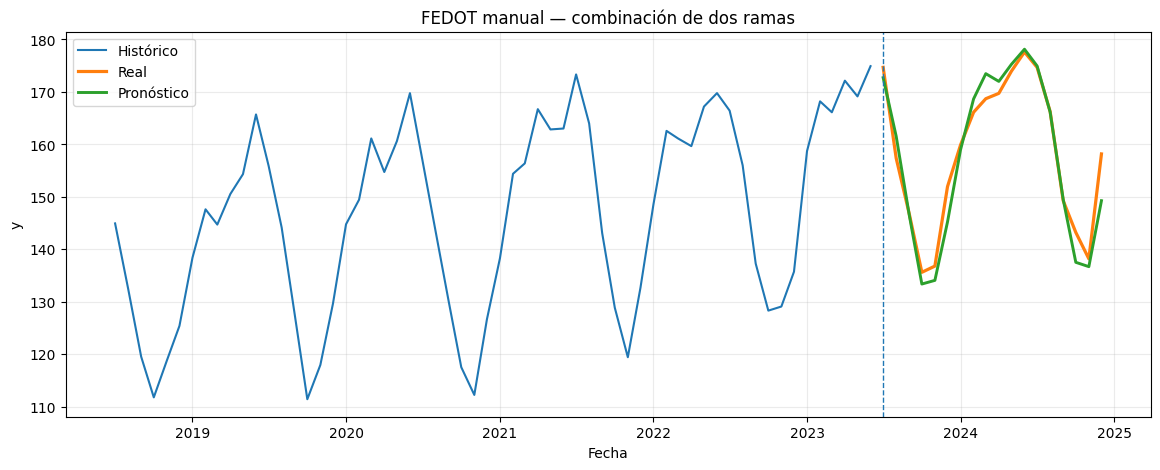

In [ ]:
forecast_compuesto = None

try:
    pipeline_compuesto = (
        PipelineBuilder()
        .add_sequence("lagged", "ridge", branch_idx=0)
        .add_sequence("glm", branch_idx=1)
        .join_branches("ridge")
        .build()
    )

    fedot_compuesto = Fedot(
        problem="ts_forecasting",
        task_params=task_fedot.task_params,
        n_jobs=-1,
        seed=RANDOM_STATE,
        logging_level=20
    )

    fedot_compuesto.fit(
        fedot_train,
        predefined_model=pipeline_compuesto
    )

    forecast_compuesto = np.asarray(
        fedot_compuesto.forecast(fedot_train, horizon=H)
    ).ravel()

    resultados.append(
        metricas(test_df["y"], forecast_compuesto, "FEDOT manual — pipeline compuesto")
    )

    grafico_forecast(
        train_df,
        test_df,
        forecast_compuesto,
        "FEDOT manual — combinación de dos ramas"
    )

except Exception as error:
    print("La variante compuesta no pudo ejecutarse con esta instalación.")
    print("El resto del notebook continúa normalmente.")
    print("Detalle técnico:", error)

# Parte C — Comparación final

## 18. Ranking de modelos

La comparación se realiza sobre el mismo test final y el mismo horizonte.

Además de la precisión, en un proyecto real deberían considerarse:

- tiempo de entrenamiento;
- estabilidad entre ventanas;
- facilidad de mantenimiento;
- explicabilidad;
- capacidad de trabajar con múltiples series;
- disponibilidad de covariables futuras;
- necesidad de intervalos de predicción.

In [ ]:
ranking = (
    pd.DataFrame(resultados)
    .drop_duplicates(subset=["Modelo"], keep="last")
    .sort_values("RMSE")
    .reset_index(drop=True)
)

ranking.index = ranking.index + 1
display(ranking.round(3))

,Modelo,MAE,RMSE,MAPE (%),sMAPE (%)
1,FEDOT manual — pipeline compuesto,2.618,3.581,1.689,1.705
2,FEDOT manual — lagged + ridge,2.644,3.631,1.712,1.730
3,FEDOT automático,2.797,3.676,1.854,1.880
4,MLForecast rec. — RandomForest,4.329,5.912,2.744,2.774
5,MLForecast rec. — LightGBM,5.013,6.174,3.187,3.222
6,MLForecast rec. — RegresionLineal,4.262,6.438,2.771,2.840
7,MLForecast directo — LightGBM,6.759,8.266,4.364,4.432
8,Naive estacional,7.948,9.751,5.172,5.385


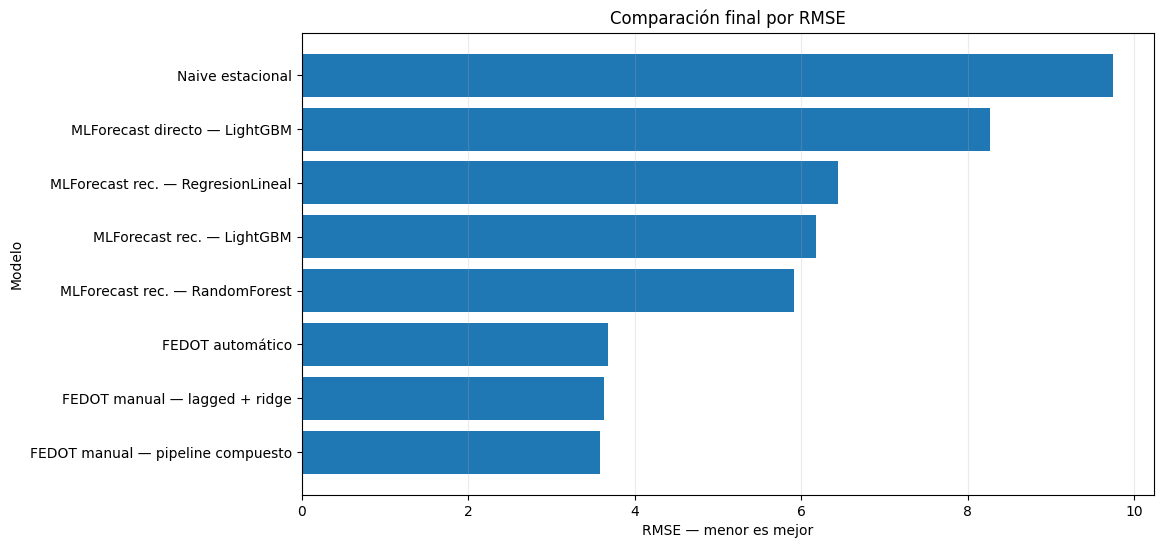

In [ ]:
plt.figure(figsize=(11, 6))
ranking_plot = ranking.sort_values("RMSE", ascending=True)
plt.barh(ranking_plot["Modelo"], ranking_plot["RMSE"])
plt.title("Comparación final por RMSE")
plt.xlabel("RMSE — menor es mejor")
plt.ylabel("Modelo")
plt.grid(axis="x", alpha=0.25)
plt.show()

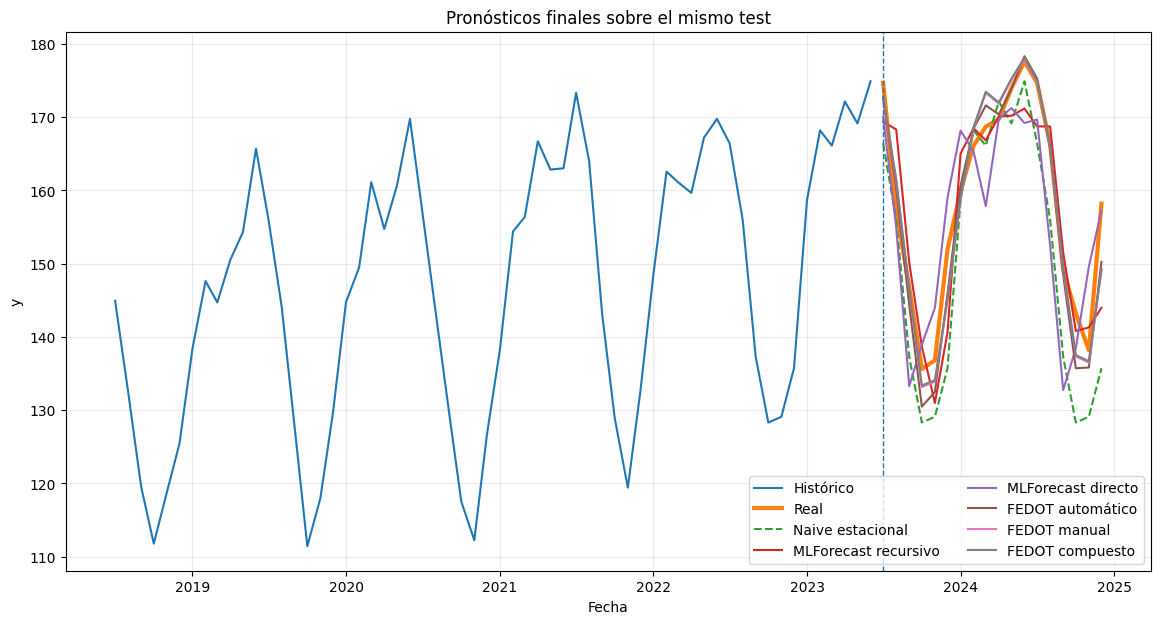

In [ ]:
plt.figure(figsize=(14, 7))
plt.plot(train_df.tail(60)["ds"], train_df.tail(60)["y"], label="Histórico")
plt.plot(test_df["ds"], test_df["y"], label="Real", linewidth=3)

plt.plot(test_df["ds"], naive_pred, label="Naive estacional", linestyle="--")
plt.plot(pred_rec["ds"], pred_rec["LightGBM"], label="MLForecast recursivo")
plt.plot(pred_direct["ds"], pred_direct["LightGBM_directo"], label="MLForecast directo")
plt.plot(test_df["ds"], forecast_auto, label="FEDOT automático")
plt.plot(test_df["ds"], forecast_manual, label="FEDOT manual")

if forecast_compuesto is not None:
    plt.plot(test_df["ds"], forecast_compuesto, label="FEDOT compuesto")

plt.axvline(test_df["ds"].min(), linestyle="--", linewidth=1)
plt.title("Pronósticos finales sobre el mismo test")
plt.xlabel("Fecha")
plt.ylabel("y")
plt.legend(ncol=2)
plt.grid(alpha=0.25)
plt.show()

## 19. Lectura de resultados

### MLForecast

Resulta especialmente conveniente cuando:

- se quieren utilizar LightGBM, XGBoost, CatBoost o modelos sklearn;
- existen muchas series con una estructura común;
- se necesitan lags y rolling features eficientes;
- se requieren covariables y validación temporal;
- se desea controlar explícitamente la estrategia recursiva o directa.

### FEDOT

Resulta especialmente conveniente cuando:

- se desea automatizar no solo el modelo, sino también la estructura del pipeline;
- se quieren combinar ramas y transformaciones;
- se acepta un mayor costo de búsqueda;
- se busca comparar un pipeline automático con arquitecturas manuales.

### Diferencia central

| MLForecast | FEDOT |
|---|---|
| Framework especializado en feature engineering temporal + regresores | Framework AutoML de pipelines compuestos |
| El usuario define lags, transformaciones y modelos | FEDOT puede buscar la arquitectura |
| Muy transparente para benchmarking | Más automatización estructural |
| Ideal para ML global a escala | Útil para explorar composiciones |

## 20. Extensiones recomendadas

Para llevar este notebook a un caso productivo:

1. Reemplazar la serie sintética por datos reales.
2. Definir el horizonte según la decisión de negocio.
3. Crear un test final completamente aislado.
4. Ajustar lags según la frecuencia:
   - diaria: 1, 7, 14, 28;
   - semanal: 1, 4, 13, 26, 52;
   - mensual: 1, 3, 6, 12, 24.
5. Agregar covariables futuras conocidas.
6. Ejecutar validación temporal con más ventanas.
7. Optimizar hiperparámetros únicamente con train/validación.
8. Evaluar estabilidad, no solo el mejor error promedio.
9. Reentrenar sobre toda la información disponible antes del forecast productivo.
10. Registrar versiones, métricas y fecha de entrenamiento.

## 21. Referencias oficiales

- MLForecast: documentación oficial de Nixtla.
- MLForecast: validación temporal, estrategia directa e intervalos conformales.
- FEDOT: documentación oficial de forecasting, pipelines automáticos y manuales.
- FEDOT 0.7.5: versión estable utilizada en este notebook.

El notebook fue diseñado para ejecución secuencial en Google Colab y utiliza una serie autocontenida para favorecer la reproducibilidad.